<a href="https://colab.research.google.com/github/joaoestella/IA-Course-Projects/blob/main/assignments/CP4_NYC_Taxi_Trip_Duration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NYC Taxi Trip Duration - Exploratory Analysis

### 🇧🇷 Português
Realize uma análise exploratória dos dados disponíveis em: https://www.kaggle.com/competitions/nyc-taxi-trip-duration

1 - Crie hipóteses e utilize gráficos para testá-las.

2 - Crie novas variáveis, caso considere pertinente para melhorar a análise ou o modelo.

3 - Treine um modelo para prever a variável *trip_duration*.

4 - Escolha e calcule métricas de avaliação do modelo.

5 - Faça uma análise relacionando a assertividade do modelo com seu uso em um sistema real, como serviços de transporte por aplicativo, por exemplo o Uber.

---

### 🇺🇸 English
Perform an exploratory data analysis using the dataset available at: https://www.kaggle.com/competitions/nyc-taxi-trip-duration

1 - Create hypotheses and use charts to test them.

2 - Create new features if you find it relevant to improve the analysis or the model.

3 - Train a model to predict the *trip_duration* variable.

4 - Choose and compute evaluation metrics for the model.

5 - Provide an analysis relating the model’s performance to its use in a real-world system, such as ride-hailing services like Uber.

# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import xgboost as xgb
from xgboost import plot_importance

# Configurações para visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

#Carregamento dos Dados

In [ ]:
train = pd.read_csv('/content/sample_data/train.csv')

#Primeira Visão dos Dados

In [ ]:
print(f"\nESTRUTURA DO DATASET:")
train.info()


ESTRUTURA DO DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205869 entries, 0 to 205868
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  205869 non-null  object 
 1   vendor_id           205869 non-null  int64  
 2   pickup_datetime     205869 non-null  object 
 3   dropoff_datetime    205869 non-null  object 
 4   passenger_count     205869 non-null  int64  
 5   pickup_longitude    205869 non-null  float64
 6   pickup_latitude     205869 non-null  float64
 7   dropoff_longitude   205869 non-null  float64
 8   dropoff_latitude    205868 non-null  float64
 9   store_and_fwd_flag  205868 non-null  object 
 10  trip_duration       205868 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 17.3+ MB


In [ ]:
print(f"\nTIPOS DE DADOS:")
for col, dtype in train.dtypes.items():
    print(f"  {col:20s}: {str(dtype):15s}")


TIPOS DE DADOS:
  id                  : object         
  vendor_id           : int64          
  pickup_datetime     : object         
  dropoff_datetime    : object         
  passenger_count     : int64          
  pickup_longitude    : float64        
  pickup_latitude     : float64        
  dropoff_longitude   : float64        
  dropoff_latitude    : float64        
  store_and_fwd_flag  : object         
  trip_duration       : float64        


In [ ]:
print(f"\nPRIMEIRAS 5 LINHAS:")
train.head()


PRIMEIRAS 5 LINHAS:


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455.0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663.0
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124.0
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429.0
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435.0


In [ ]:
print(f"\nÚLTIMAS 5 LINHAS:")
train.tail()


ÚLTIMAS 5 LINHAS:


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
205864,id3511045,2,2016-04-17 12:44:47,2016-04-17 13:13:43,1,-73.985359,40.727528,-73.978241,40.772907,N,1736.0
205865,id1355766,1,2016-02-28 20:38:16,2016-02-28 20:52:00,1,-73.947533,40.799072,-73.987312,40.761314,N,824.0
205866,id1947440,1,2016-02-19 17:56:52,2016-02-19 18:14:27,1,-73.952339,40.783947,-73.977074,40.743134,N,1055.0
205867,id0866397,2,2016-03-23 15:22:23,2016-03-23 15:30:15,4,-73.962425,40.778957,-73.970596,40.767746,N,472.0
205868,id2938384,2,2016-05-21 15:13:31,2016-05-21 15:18:40,6,-73.978256,40.773052,-73.978200,NaN,NaN,NaN


In [ ]:
print(f"\nVALORES ÚNICOS POR COLUNA:")
for col in train.columns:
    unique_count = train[col].nunique()
    total_count = len(train)
    percentage = (unique_count / total_count) * 100
    print(f"  {col:20s}: {unique_count:8,} únicos ({percentage:5.1f}% do total)")


VALORES ÚNICOS POR COLUNA:
  id                  :  205,869 únicos (100.0% do total)
  vendor_id           :        2 únicos (  0.0% do total)
  pickup_datetime     :  204,221 únicos ( 99.2% do total)
  dropoff_datetime    :  204,259 únicos ( 99.2% do total)
  passenger_count     :        7 únicos (  0.0% do total)
  pickup_longitude    :   14,810 únicos (  7.2% do total)
  pickup_latitude     :   30,882 únicos ( 15.0% do total)
  dropoff_longitude   :   19,249 únicos (  9.4% do total)
  dropoff_latitude    :   38,202 únicos ( 18.6% do total)
  store_and_fwd_flag  :        2 únicos (  0.0% do total)
  trip_duration       :    4,788 únicos (  2.3% do total)


# Qualidade dos Dados

In [ ]:
# Verificar valores Faltando
print(" VALORES Faltando:")
missing_info = pd.DataFrame({
    'Coluna': train.columns,
    'Missing_Count': train.isnull().sum(),
    'Missing_Percent': (train.isnull().sum() / len(train)) * 100,
    'Dtype': train.dtypes
})
print(missing_info)

total_missing = train.isnull().sum().sum()
print(f"\n Total de valores Faltando: {total_missing}")

 VALORES Faltando:
                                Coluna  Missing_Count  Missing_Percent  \
id                                  id              0         0.000000   
vendor_id                    vendor_id              0         0.000000   
pickup_datetime        pickup_datetime              0         0.000000   
dropoff_datetime      dropoff_datetime              0         0.000000   
passenger_count        passenger_count              0         0.000000   
pickup_longitude      pickup_longitude              0         0.000000   
pickup_latitude        pickup_latitude              0         0.000000   
dropoff_longitude    dropoff_longitude              0         0.000000   
dropoff_latitude      dropoff_latitude              1         0.000486   
store_and_fwd_flag  store_and_fwd_flag              1         0.000486   
trip_duration            trip_duration              1         0.000486   

                      Dtype  
id                   object  
vendor_id             int64  
pi

In [ ]:
# Verificar duplicatas
print(f"\nDUPLICATAS:")
duplicates = train.duplicated().sum()
print(f"Registros completamente duplicados: {duplicates:,}")
print(f"Percentual de duplicatas: {duplicates/len(train)*100:.4f}%")


DUPLICATAS:
Registros completamente duplicados: 0
Percentual de duplicatas: 0.0000%


In [ ]:
# Verificar duplicatas por ID
id_duplicates = train['id'].duplicated().sum()
print(f"IDs duplicados: {id_duplicates}")

IDs duplicados: 0


#Análise Detalhada da Duração das Viagens

In [ ]:
# Conversão para minutos para melhor interpretação
train['trip_duration_minutes'] = train['trip_duration'] / 60
train['trip_duration_hours'] = train['trip_duration'] / 3600

print("ESTATÍSTICAS DESCRITIVAS - TRIP_DURATION:")
desc_stats = train[['trip_duration', 'trip_duration_minutes', 'trip_duration_hours']].describe()
print(desc_stats)

print(f"\nESTATÍSTICAS ADICIONAIS:")
print(f"Assimetria: {stats.skew(train['trip_duration']):.4f}")
print(f"Curtose: {stats.kurtosis(train['trip_duration']):.4f}")
print(f"Coeficiente de Variação: {train['trip_duration'].std()/train['trip_duration'].mean():.4f}")

print(f"\nINTERPRETAÇÃO EM DIFERENTES UNIDADES:")
print(f"Duração mínima: {train['trip_duration'].min()} segundos ({train['trip_duration_minutes'].min():.1f} min)")
print(f"Duração máxima: {train['trip_duration'].max()} segundos ({train['trip_duration_hours'].max():.1f} horas)")
print(f"Duração média: {train['trip_duration'].mean():.0f} segundos ({train['trip_duration_minutes'].mean():.1f} min)")
print(f"Duração mediana: {train['trip_duration'].median():.0f} segundos ({train['trip_duration_minutes'].median():.1f} min)")

ESTATÍSTICAS DESCRITIVAS - TRIP_DURATION:
       trip_duration  trip_duration_minutes  trip_duration_hours
count  205868.000000          205868.000000        205868.000000
mean      947.026765              15.783779             0.263063
std      3106.974223              51.782904             0.863048
min         1.000000               0.016667             0.000278
25%       395.000000               6.583333             0.109722
50%       661.000000              11.016667             0.183611
75%      1073.000000              17.883333             0.298056
max     86390.000000            1439.833333            23.997222

ESTATÍSTICAS ADICIONAIS:
Assimetria: nan
Curtose: nan
Coeficiente de Variação: 3.2808

INTERPRETAÇÃO EM DIFERENTES UNIDADES:
Duração mínima: 1.0 segundos (0.0 min)
Duração máxima: 86390.0 segundos (24.0 horas)
Duração média: 947 segundos (15.8 min)
Duração mediana: 661 segundos (11.0 min)


In [ ]:
# Percentis detalhados
print(f"\nANÁLISE DE PERCENTIS (em minutos):")
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.9]
for p in percentiles:
    value_min = train['trip_duration_minutes'].quantile(p/100)
    value_sec = train['trip_duration'].quantile(p/100)
    print(f"  P{p:4.1f}: {value_min:7.1f} min ({value_sec:8.0f} seg)")


ANÁLISE DE PERCENTIS (em minutos):
  P 1.0:     1.4 min (      87 seg)
  P 5.0:     3.0 min (     180 seg)
  P10.0:     4.1 min (     244 seg)
  P25.0:     6.6 min (     395 seg)
  P50.0:    11.0 min (     661 seg)
  P75.0:    17.9 min (    1073 seg)
  P90.0:    27.2 min (    1633 seg)
  P95.0:    35.0 min (    2102 seg)
  P99.0:    56.8 min (    3406 seg)
  P99.9:  1407.6 min (   84455 seg)


# Outliers e Categorias de Viagem

In [ ]:
# Identificação de outliers usando IQR
Q1 = train['trip_duration_minutes'].quantile(0.25)
Q3 = train['trip_duration_minutes'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = len(train[(train['trip_duration_minutes'] < lower_bound) |
                          (train['trip_duration_minutes'] > upper_bound)])

print(f"\nANÁLISE DE OUTLIERS (Método IQR):")
print(f"Q1 (25%): {Q1:.1f} min")
print(f"Q3 (75%): {Q3:.1f} min")
print(f"IQR: {IQR:.1f} min")
print(f"Limite inferior: {lower_bound:.1f} min")
print(f"Limite superior: {upper_bound:.1f} min")
print(f"Outliers encontrados: {outliers_count:,} ({outliers_count/len(train)*100:.2f}%)")


ANÁLISE DE OUTLIERS (Método IQR):
Q1 (25%): 6.6 min
Q3 (75%): 17.9 min
IQR: 11.3 min
Limite inferior: -10.4 min
Limite superior: 34.8 min
Outliers encontrados: 10,441 (5.07%)


In [ ]:
# Categorização das viagens por duração
def categorize_trip(minutes):
    if minutes < 5:
        return 'Muito Curta (< 5min)'
    elif minutes < 15:
        return 'Curta (5-15min)'
    elif minutes < 30:
        return 'Média (15-30min)'
    elif minutes < 60:
        return 'Longa (30-60min)'
    else:
        return 'Muito Longa (> 1h)'

train['trip_category'] = train['trip_duration_minutes'].apply(categorize_trip)

print(f"\nCATEGORIZAÇÃO DAS VIAGENS:")
trip_categories = train['trip_category'].value_counts()
for category, count in trip_categories.items():
    percentage = (count / len(train)) * 100
    print(f"  {category:20s}: {count:8,} viagens ({percentage:5.1f}%)")


CATEGORIZAÇÃO DAS VIAGENS:
  Curta (5-15min)     :  105,122 viagens ( 51.1%)
  Média (15-30min)    :   53,333 viagens ( 25.9%)
  Muito Curta (< 5min):   31,431 viagens ( 15.3%)
  Longa (30-60min)    :   14,298 viagens (  6.9%)
  Muito Longa (> 1h)  :    1,685 viagens (  0.8%)


# Análise Temporal

In [ ]:
# Converter datetime
train['pickup_datetime'] = pd.to_datetime(train['pickup_datetime'])

# Extrair componentes temporais
train['pickup_year'] = train['pickup_datetime'].dt.year
train['pickup_month'] = train['pickup_datetime'].dt.month
train['pickup_day'] = train['pickup_datetime'].dt.day
train['pickup_hour'] = train['pickup_datetime'].dt.hour
train['pickup_weekday'] = train['pickup_datetime'].dt.weekday
train['pickup_weekend'] = (train['pickup_weekday'] >= 5).astype(int)
train['pickup_week'] = train['pickup_datetime'].dt.isocalendar().week

print(f"PERÍODO DOS DADOS:")
print(f"Data inicial: {train['pickup_datetime'].min()}")
print(f"Data final: {train['pickup_datetime'].max()}")
print(f"Período total: {(train['pickup_datetime'].max() - train['pickup_datetime'].min()).days} dias")

print(f"\nDISTRIBUIÇÃO TEMPORAL:")
print(f"Anos únicos: {sorted(train['pickup_year'].unique())}")
print(f"Meses únicos: {sorted(train['pickup_month'].unique())}")
print(f"Dias do mês únicos: {sorted(train['pickup_day'].unique())}")

PERÍODO DOS DADOS:
Data inicial: 2016-01-01 00:00:17
Data final: 2016-06-30 23:58:38
Período total: 181 dias

DISTRIBUIÇÃO TEMPORAL:
Anos únicos: [np.int32(2016)]
Meses únicos: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]
Dias do mês únicos: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


In [ ]:
# Mapeamentos para melhor visualização
month_names = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
               7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}
weekday_names = {0: 'Seg', 1: 'Ter', 2: 'Qua', 3: 'Qui', 4: 'Sex', 5: 'Sáb', 6: 'Dom'}

train['month_name'] = train['pickup_month'].map(month_names)
train['weekday_name'] = train['pickup_weekday'].map(weekday_names)

# Criar período do dia
def get_time_period(hour):
    if 5 <= hour < 12:
        return 'Manhã'
    elif 12 <= hour < 18:
        return 'Tarde'
    elif 18 <= hour < 22:
        return 'Noite'
    else:
        return 'Madrugada'

train['time_period'] = train['pickup_hour'].apply(get_time_period)

print(f"\nANÁLISE POR HORA DO DIA:")
hourly_stats = train.groupby('pickup_hour').agg({
    'trip_duration_minutes': ['count', 'mean', 'median', 'std']
}).round(2)
hourly_stats.columns = ['Contagem', 'Média_Min', 'Mediana_Min', 'DesvPad_Min']
print(hourly_stats)



ANÁLISE POR HORA DO DIA:
             Contagem  Média_Min  Mediana_Min  DesvPad_Min
pickup_hour                                               
0                7539      15.29        10.70        59.24
1                5352      15.68        10.03        71.36
2                3911      13.72         9.93        54.82
3                2918      12.80         9.89        39.87
4                2273      17.93        10.40        88.57
5                2208      12.96         8.80        34.25
6                4676      11.69         7.72        28.15
7                7986      13.46         9.40        35.56
8                9354      14.96        10.87        42.45
9                9493      16.11        11.35        53.49
10               9278      15.41        11.33        39.34
11               9650      16.09        11.77        46.85
12              10325      16.20        11.70        48.10
13               9859      16.39        11.63        47.65
14              10541      17.

In [ ]:
print(f"\nANÁLISE POR DIA DA SEMANA:")
weekday_stats = train.groupby('weekday_name').agg({
    'trip_duration_minutes': ['count', 'mean', 'median']
}).round(2)
weekday_stats.columns = ['Contagem', 'Média_Min', 'Mediana_Min']
# Reordenar pelos dias da semana
weekday_order = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
weekday_stats = weekday_stats.reindex(weekday_order)
print(weekday_stats)


ANÁLISE POR DIA DA SEMANA:
              Contagem  Média_Min  Mediana_Min
weekday_name                                  
Seg              26523      15.04        10.52
Ter              28425      16.19        11.25
Qua              29852      16.20        11.50
Qui              30955      16.65        11.90
Sex              31288      16.74        11.50
Sáb              31226      15.11        10.53
Dom              27599      14.34         9.95


In [ ]:
print(f"\nANÁLISE POR PERÍODO DO DIA:")
period_stats = train.groupby('time_period').agg({
    'trip_duration_minutes': ['count', 'mean', 'median', 'std']
}).round(2)
period_stats.columns = ['Contagem', 'Média_Min', 'Mediana_Min', 'DesvPad_Min']
print(period_stats)


ANÁLISE POR PERÍODO DO DIA:
             Contagem  Média_Min  Mediana_Min  DesvPad_Min
time_period                                               
Madrugada       43052      15.23        10.68        58.07
Manhã           52645      14.85        10.57        42.71
Noite           49402      15.40        10.93        54.03
Tarde           60769      17.30        11.77        52.33


In [ ]:
print(f"\nANÁLISE POR MÊS:")
monthly_stats = train.groupby('month_name').agg({
    'trip_duration_minutes': ['count', 'mean', 'median']
}).round(2)
monthly_stats.columns = ['Contagem', 'Média_Min', 'Mediana_Min']
print(monthly_stats)


ANÁLISE POR MÊS:
            Contagem  Média_Min  Mediana_Min
month_name                                  
Abr            35816      15.54        11.25
Fev            33663      14.66        10.58
Jan            32542      15.02        10.50
Jun            32785      17.05        11.55
Mai            34714      16.71        11.45
Mar            36348      15.72        10.88


In [ ]:
print(f"\nCOMPARAÇÃO FIM DE SEMANA vs DIAS ÚTEIS:")
weekend_comparison = train.groupby('pickup_weekend').agg({
    'trip_duration_minutes': ['count', 'mean', 'median', 'std']
}).round(2)
weekend_comparison.columns = ['Contagem', 'Média_Min', 'Mediana_Min', 'DesvPad_Min']
weekend_comparison.index = ['Dias Úteis', 'Fim de Semana']
print(weekend_comparison)



COMPARAÇÃO FIM DE SEMANA vs DIAS ÚTEIS:
               Contagem  Média_Min  Mediana_Min  DesvPad_Min
Dias Úteis       147043      16.20        11.35        51.27
Fim de Semana     58825      14.75        10.27        53.03


#Visualizações Exploratorias

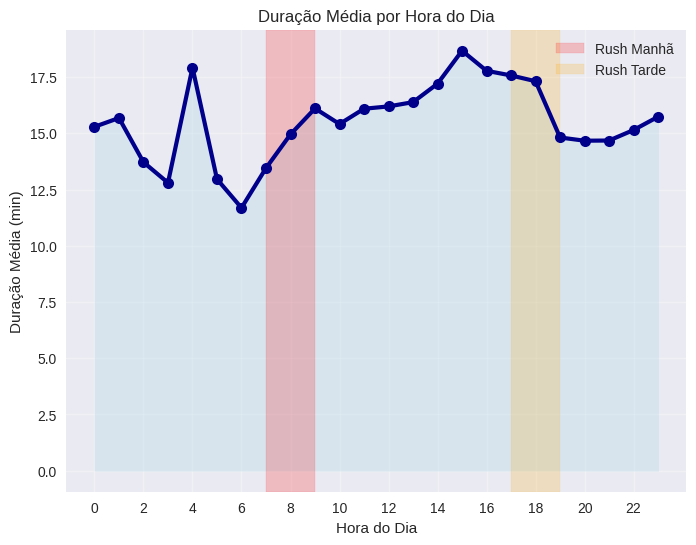

In [ ]:
plt.figure(figsize=(8,6))
hourly_mean = train.groupby('pickup_hour')['trip_duration_minutes'].mean()
plt.plot(hourly_mean.index, hourly_mean.values, marker='o', linewidth=3, markersize=8, color='darkblue')
plt.fill_between(hourly_mean.index, hourly_mean.values, alpha=0.3, color='lightblue')
plt.xlabel('Hora do Dia')
plt.ylabel('Duração Média (min)')
plt.title('Duração Média por Hora do Dia')
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3)

# Rush hours
plt.axvspan(7, 9, alpha=0.2, color='red', label='Rush Manhã')
plt.axvspan(17, 19, alpha=0.2, color='orange', label='Rush Tarde')
plt.legend()
plt.show()


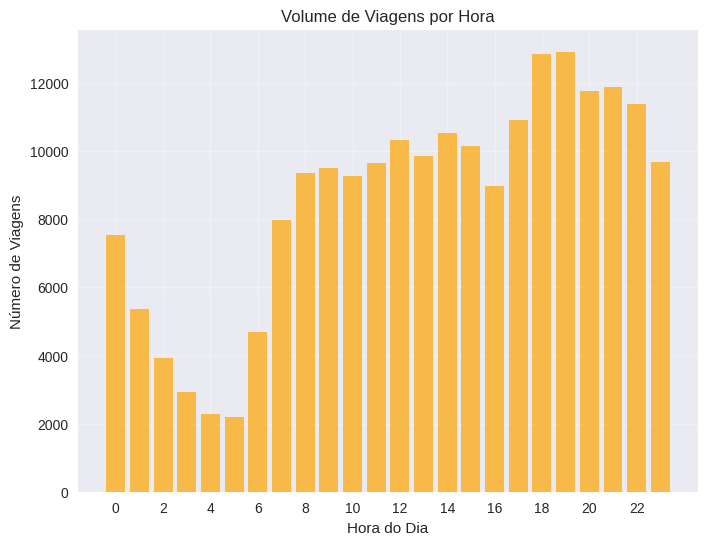

In [ ]:
plt.figure(figsize=(8,6))
hourly_count = train.groupby('pickup_hour').size()
plt.bar(hourly_count.index, hourly_count.values, color='orange', alpha=0.7)
plt.xlabel('Hora do Dia')
plt.ylabel('Número de Viagens')
plt.title('Volume de Viagens por Hora')
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3)
plt.show()


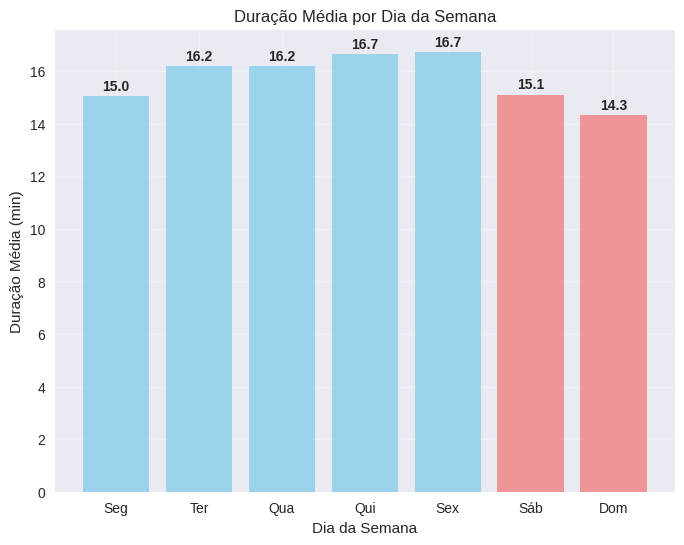

In [ ]:
plt.figure(figsize=(8,6))
weekday_mean = train.groupby('weekday_name')['trip_duration_minutes'].mean().reindex(weekday_order)
colors = ['skyblue' if day in ['Seg', 'Ter', 'Qua', 'Qui', 'Sex'] else 'lightcoral' for day in weekday_order]
bars = plt.bar(weekday_order, weekday_mean.values, color=colors, alpha=0.8)
plt.xlabel('Dia da Semana')
plt.ylabel('Duração Média (min)')
plt.title('Duração Média por Dia da Semana')
plt.grid(True, alpha=0.3)

# Adicionar valores
for bar, value in zip(bars, weekday_mean.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
             f'{value:.1f}', ha='center', va='bottom', fontweight='bold')
plt.show()


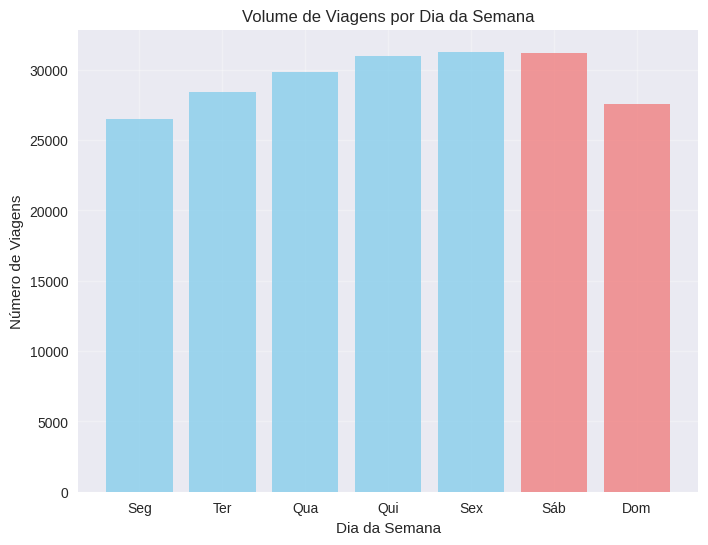

In [ ]:
plt.figure(figsize=(8,6))
weekday_count = train.groupby('weekday_name').size().reindex(weekday_order)
colors = ['skyblue' if day in ['Seg', 'Ter', 'Qua', 'Qui', 'Sex'] else 'lightcoral' for day in weekday_order]
plt.bar(weekday_order, weekday_count.values, color=colors, alpha=0.8)
plt.xlabel('Dia da Semana')
plt.ylabel('Número de Viagens')
plt.title('Volume de Viagens por Dia da Semana')
plt.grid(True, alpha=0.3)
plt.show()


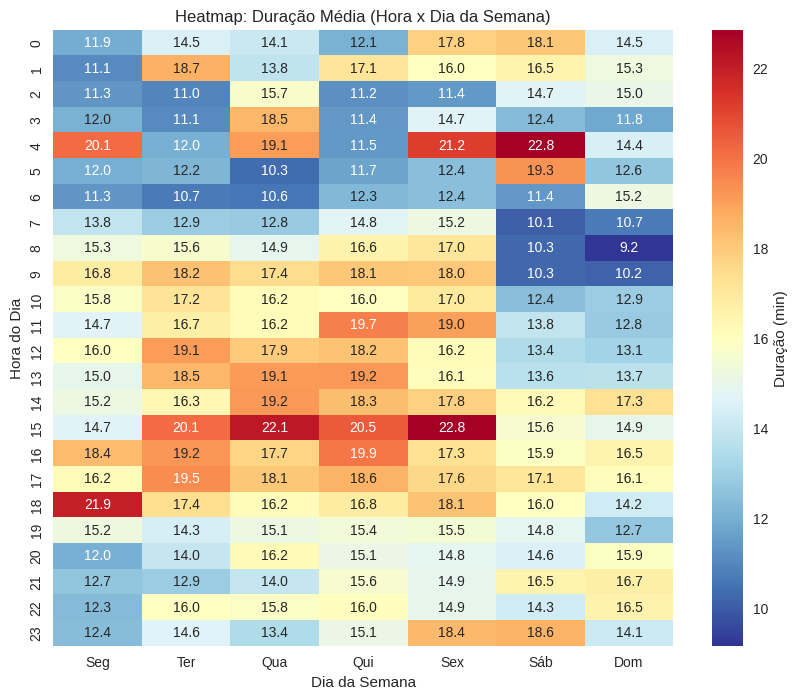

In [ ]:
plt.figure(figsize=(10,8))
pivot_duration = train.pivot_table(
    values='trip_duration_minutes',
    index='pickup_hour',
    columns='pickup_weekday',
    aggfunc='mean'
)
pivot_duration.columns = weekday_order
sns.heatmap(pivot_duration, annot=True, fmt='.1f', cmap='RdYlBu_r', cbar_kws={'label': 'Duração (min)'})
plt.title('Heatmap: Duração Média (Hora x Dia da Semana)')
plt.xlabel('Dia da Semana')
plt.ylabel('Hora do Dia')
plt.show()


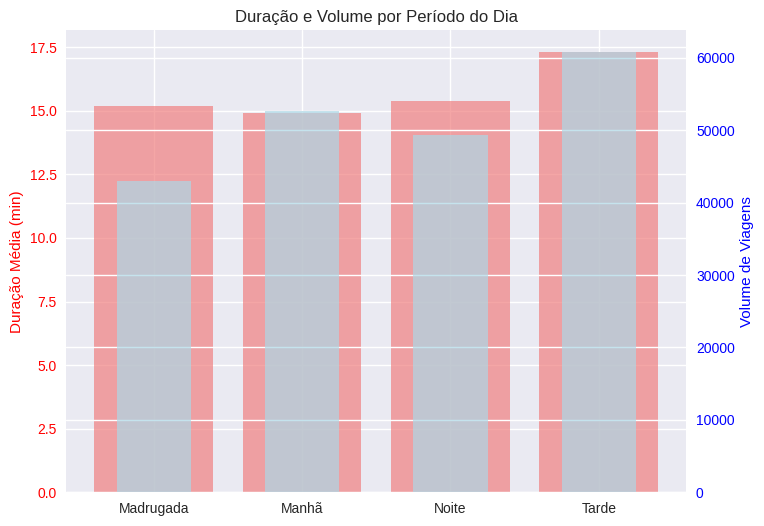

In [ ]:
plt.figure(figsize=(8,6))
period_data = train.groupby('time_period').agg({
    'trip_duration_minutes': 'mean',
    'id': 'count'
}).round(1)

ax_main = plt.gca()
ax_twin = ax_main.twinx()

bars1 = ax_main.bar(period_data.index, period_data['trip_duration_minutes'],
                   color='lightcoral', alpha=0.7, label='Duração Média')
bars2 = ax_twin.bar(period_data.index, period_data['id'],
                   width=0.5, color='lightblue', alpha=0.7, label='Volume')

ax_main.set_ylabel('Duração Média (min)', color='red')
ax_twin.set_ylabel('Volume de Viagens', color='blue')
ax_main.set_title('Duração e Volume por Período do Dia')
ax_main.tick_params(axis='y', labelcolor='red')
ax_twin.tick_params(axis='y', labelcolor='blue')
plt.show()


#Análise de Variáveis Categóricas

In [ ]:
print(f"\nVENDOR_ID - Análise Completa:")
vendor_analysis = train.groupby('vendor_id').agg({
    'trip_duration_minutes': ['count', 'mean', 'median', 'std', 'min', 'max']
}).round(2)
vendor_analysis.columns = ['Contagem', 'Média', 'Mediana', 'DesvPad', 'Mínimo', 'Máximo']
print(vendor_analysis)

vendor_distribution = train['vendor_id'].value_counts()
print(f"\nDistribuição de Vendor ID:")
for vendor, count in vendor_distribution.items():
    percentage = (count / len(train)) * 100
    print(f"  Vendor {vendor}: {count:,} viagens ({percentage:.1f}%)")


VENDOR_ID - Análise Completa:
           Contagem  Média  Mediana  DesvPad  Mínimo   Máximo
vendor_id                                                    
1             95722  13.86    10.95    11.26    0.02   720.58
2            110146  17.45    11.08    69.97    0.03  1439.83

Distribuição de Vendor ID:
  Vendor 2: 110,147 viagens (53.5%)
  Vendor 1: 95,722 viagens (46.5%)


In [ ]:
print(f"\nPASSENGER_COUNT - Análise Completa:")
passenger_analysis = train.groupby('passenger_count').agg({
    'trip_duration_minutes': ['count', 'mean', 'median', 'std']
}).round(2)
passenger_analysis.columns = ['Contagem', 'Média', 'Mediana', 'DesvPad']
print(passenger_analysis)

passenger_distribution = train['passenger_count'].value_counts().sort_index()
print(f"\nDistribuição de Passenger Count:")
for passengers, count in passenger_distribution.items():
    percentage = (count / len(train)) * 100
    print(f"  {passengers} passageiro(s): {count:,} viagens ({percentage:.1f}%)")


PASSENGER_COUNT - Análise Completa:
                 Contagem   Média  Mediana  DesvPad
passenger_count                                    
0                       3  478.11     2.58   825.82
1                  145838   15.34    10.87    47.98
2                   29714   16.51    11.47    52.64
3                    8488   17.99    11.63    70.70
4                    3973   15.67    11.45    40.70
5                   11109   16.69    11.18    63.62
6                    6743   17.76    11.03    74.93

Distribuição de Passenger Count:
  0 passageiro(s): 3 viagens (0.0%)
  1 passageiro(s): 145,838 viagens (70.8%)
  2 passageiro(s): 29,714 viagens (14.4%)
  3 passageiro(s): 8,488 viagens (4.1%)
  4 passageiro(s): 3,973 viagens (1.9%)
  5 passageiro(s): 11,109 viagens (5.4%)
  6 passageiro(s): 6,744 viagens (3.3%)


In [ ]:
print(f"\nSTORE_AND_FWD_FLAG - Análise Completa:")
flag_analysis = train.groupby('store_and_fwd_flag').agg({
    'trip_duration_minutes': ['count', 'mean', 'median', 'std']
}).round(2)
flag_analysis.columns = ['Contagem', 'Média', 'Mediana', 'DesvPad']
print(flag_analysis)

flag_distribution = train['store_and_fwd_flag'].value_counts()
print(f"\nDistribuição de Store and Forward Flag:")
for flag, count in flag_distribution.items():
    percentage = (count / len(train)) * 100
    flag_meaning = "Não armazenado" if flag == 'N' else "Armazenado antes do envio"
    print(f"  {flag} ({flag_meaning}): {count:,} viagens ({percentage:.1f}%)")


STORE_AND_FWD_FLAG - Análise Completa:
                    Contagem  Média  Mediana  DesvPad
store_and_fwd_flag                                   
N                     204662  15.77    11.02    51.92
Y                       1206  17.64    13.36    14.66

Distribuição de Store and Forward Flag:
  N (Não armazenado): 204,662 viagens (99.4%)
  Y (Armazenado antes do envio): 1,206 viagens (0.6%)


#Criação de Novas Features

In [ ]:
train['pickup_datetime'] = pd.to_datetime(train['pickup_datetime'])
if 'dropoff_datetime' in train.columns:
    train['dropoff_datetime'] = pd.to_datetime(train['dropoff_datetime'])

In [ ]:
def create_features(df):
    """Cria novas features baseadas nos dados existentes"""
    df = df.copy()

    # Features temporais
    df['pickup_hour'] = df['pickup_datetime'].dt.hour
    df['pickup_day'] = df['pickup_datetime'].dt.day
    df['pickup_month'] = df['pickup_datetime'].dt.month
    df['pickup_weekday'] = df['pickup_datetime'].dt.weekday
    df['pickup_weekend'] = (df['pickup_weekday'] >= 5).astype(int)

    # Períodos do dia
    def get_time_period(hour):
        if 6 <= hour < 12:
            return 'morning'
        elif 12 <= hour < 18:
            return 'afternoon'
        elif 18 <= hour < 24:
            return 'evening'
        else:
            return 'night'

    df['time_period'] = df['pickup_hour'].apply(get_time_period)
    df['is_rush_hour'] = ((df['pickup_hour'].between(7, 9)) |
                          (df['pickup_hour'].between(17, 19))).astype(int)

    # Features geográficas
    df['distance_euclidean'] = np.sqrt(
        (df['pickup_longitude'] - df['dropoff_longitude'])**2 +
        (df['pickup_latitude'] - df['dropoff_latitude'])**2
    )

    df['distance_manhattan'] = (abs(df['pickup_longitude'] - df['dropoff_longitude']) +
                               abs(df['pickup_latitude'] - df['dropoff_latitude']))

    # Centro de Manhattan aproximado
    manhattan_center = (-73.9857, 40.7484)
    df['pickup_distance_to_center'] = np.sqrt(
        (df['pickup_longitude'] - manhattan_center[0])**2 +
        (df['pickup_latitude'] - manhattan_center[1])**2
    )

    # Features categóricas
    df['store_and_fwd_flag_encoded'] = (df['store_and_fwd_flag'] == 'Y').astype(int)

    # Remover outliers extremos de trip_duration (acima de 3 horas = 10800 segundos)
    df = df[df['trip_duration'] <= 10800]
    df = df[df['trip_duration'] >= 60]  # Pelo menos 1 minuto

    return df

train = create_features(train)
print("Features criadas:")
new_features = ['pickup_hour', 'pickup_weekday', 'pickup_weekend', 'time_period',
               'is_rush_hour', 'distance_euclidean', 'distance_manhattan',
               'pickup_distance_to_center', 'store_and_fwd_flag_encoded']
print(new_features)

Features criadas:
['pickup_hour', 'pickup_weekday', 'pickup_weekend', 'time_period', 'is_rush_hour', 'distance_euclidean', 'distance_manhattan', 'pickup_distance_to_center', 'store_and_fwd_flag_encoded']


In [ ]:
# Estatísticas descritivas
print("\nESTATÍSTICAS DESCRITIVAS")
print("="*50)
print(train['trip_duration'].describe())

print(f"\nCorrelações com trip_duration:")
numeric_cols = ['passenger_count', 'distance_euclidean', 'distance_manhattan',
               'pickup_hour', 'pickup_weekday', 'is_rush_hour', 'pickup_distance_to_center']
correlations = train[numeric_cols + ['trip_duration']].corr()['trip_duration'].sort_values(ascending=False)
print(correlations[:-1])  # Excluir autocorrelação



ESTATÍSTICAS DESCRITIVAS
count    204354.000000
mean        840.771798
std         657.888241
min          60.000000
25%         399.000000
50%         664.000000
75%        1074.000000
max       10571.000000
Name: trip_duration, dtype: float64

Correlações com trip_duration:
trip_duration                1.000000
distance_manhattan           0.675142
distance_euclidean           0.659133
pickup_distance_to_center    0.317878
pickup_hour                  0.032882
passenger_count              0.007724
is_rush_hour                 0.000896
Name: trip_duration, dtype: float64


# Análise Gráfica

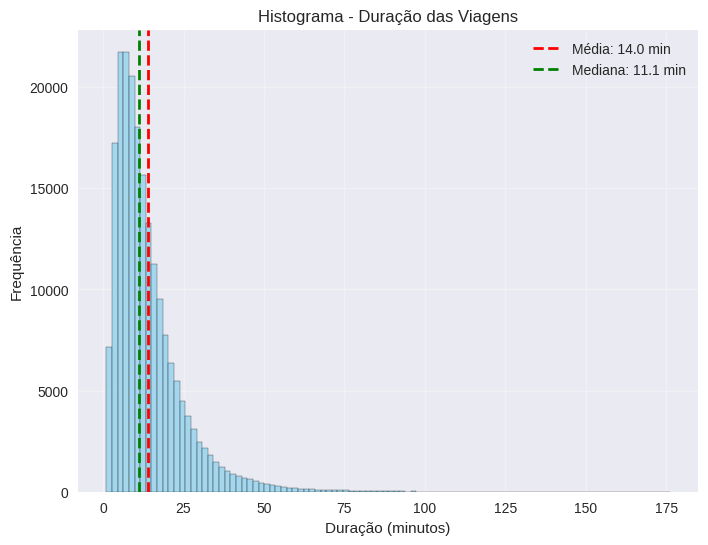

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(train['trip_duration_minutes'], bins=100, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(train['trip_duration_minutes'].mean(), color='red', linestyle='--',
            label=f'Média: {train["trip_duration_minutes"].mean():.1f} min', linewidth=2)
plt.axvline(train['trip_duration_minutes'].median(), color='green', linestyle='--',
            label=f'Mediana: {train["trip_duration_minutes"].median():.1f} min', linewidth=2)
plt.xlabel('Duração (minutos)')
plt.ylabel('Frequência')
plt.title('Histograma - Duração das Viagens')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

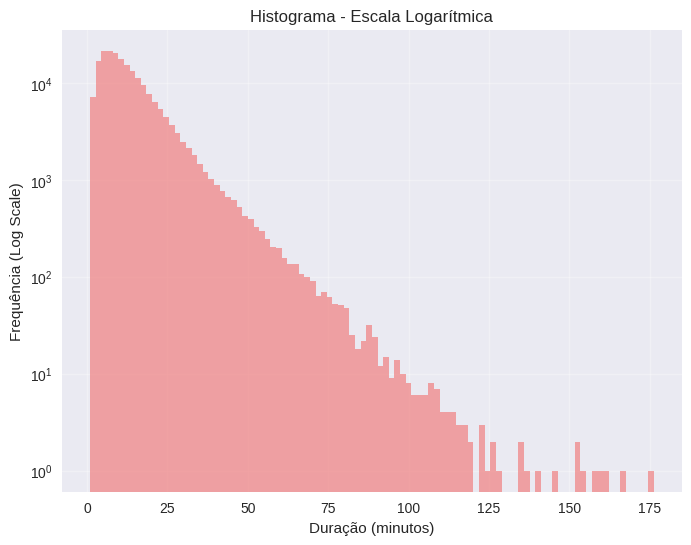

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(train['trip_duration_minutes'], bins=100, alpha=0.7, color='lightcoral')
plt.xlabel('Duração (minutos)')
plt.ylabel('Frequência (Log Scale)')
plt.title('Histograma - Escala Logarítmica')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()


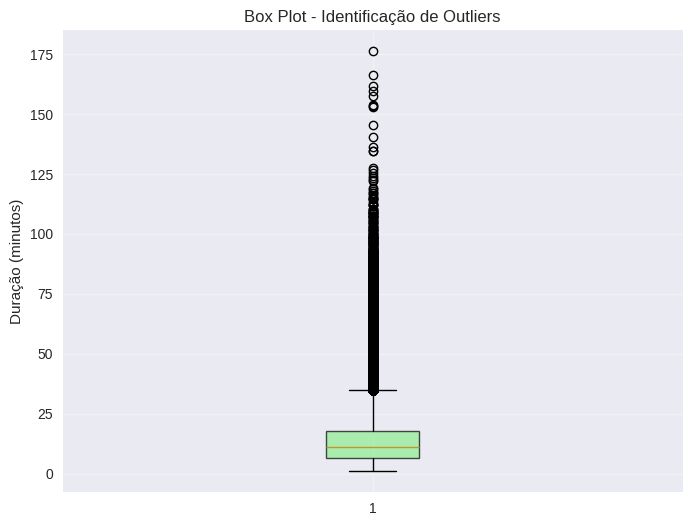

In [ ]:
plt.figure(figsize=(8,6))
plt.boxplot(train['trip_duration_minutes'], patch_artist=True,
            boxprops=dict(facecolor='lightgreen', alpha=0.7))
plt.ylabel('Duração (minutos)')
plt.title('Box Plot - Identificação de Outliers')
plt.grid(True, alpha=0.3)
plt.show()


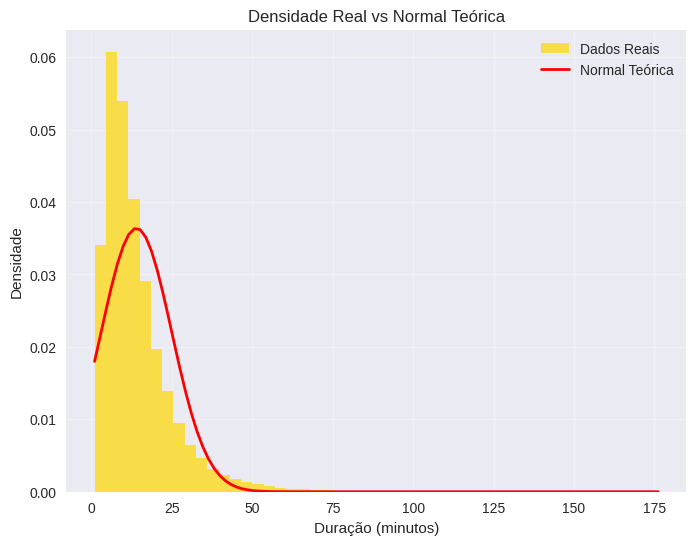

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(train['trip_duration_minutes'], bins=50, density=True, alpha=0.7, color='gold', label='Dados Reais')
mean_val = train['trip_duration_minutes'].mean()
std_val = train['trip_duration_minutes'].std()
x_norm = np.linspace(train['trip_duration_minutes'].min(), train['trip_duration_minutes'].max(), 100)
plt.plot(x_norm, stats.norm.pdf(x_norm, mean_val, std_val), 'r-', linewidth=2, label='Normal Teórica')
plt.xlabel('Duração (minutos)')
plt.ylabel('Densidade')
plt.title('Densidade Real vs Normal Teórica')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


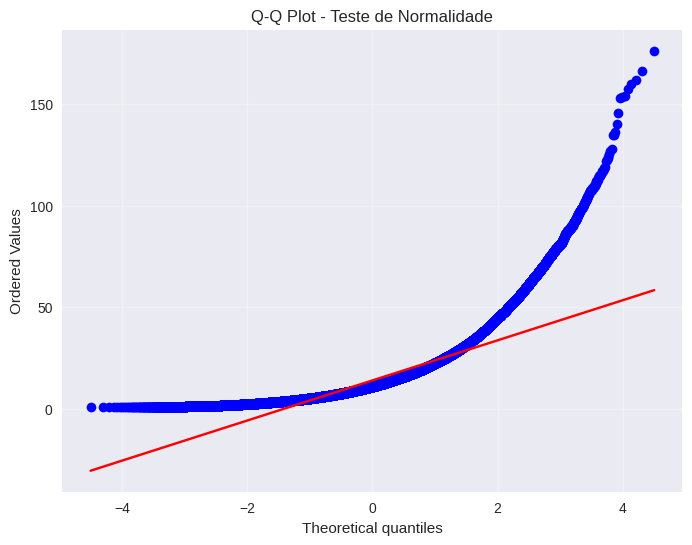

In [ ]:
plt.figure(figsize=(8,6))
stats.probplot(train['trip_duration_minutes'], dist="norm", plot=plt)
plt.title('Q-Q Plot - Teste de Normalidade')
plt.grid(True, alpha=0.3)
plt.show()


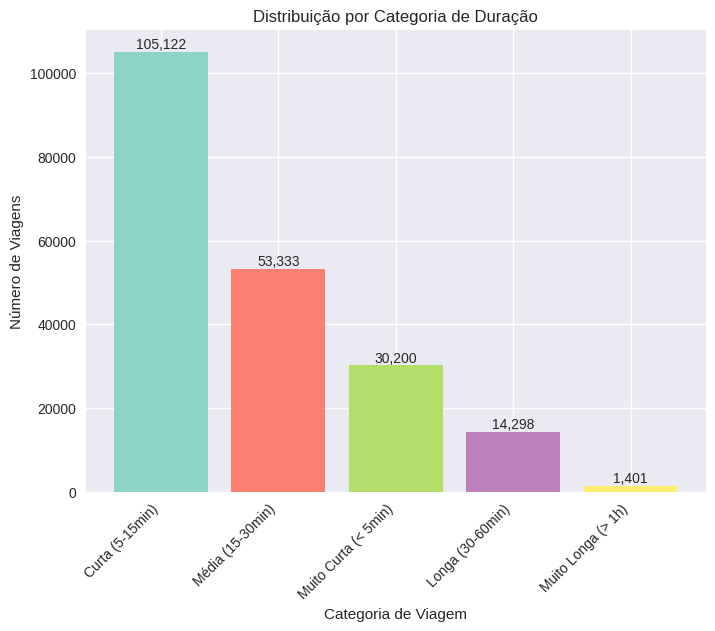

In [ ]:
plt.figure(figsize=(8,6))
category_counts = train['trip_category'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(category_counts)))
bars = plt.bar(range(len(category_counts)), category_counts.values, color=colors)
plt.xlabel('Categoria de Viagem')
plt.ylabel('Número de Viagens')
plt.title('Distribuição por Categoria de Duração')
plt.xticks(range(len(category_counts)), category_counts.index, rotation=45, ha='right')

# Adicionar valores nas barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.show()


# Preparação para Modelagem

In [ ]:
# Selecionar features para o modelo
feature_columns = [
    'vendor_id', 'passenger_count', 'pickup_hour', 'pickup_weekday',
    'pickup_weekend', 'is_rush_hour', 'distance_euclidean',
    'distance_manhattan', 'pickup_distance_to_center', 'store_and_fwd_flag_encoded'
]

# One-hot encoding para time_period
time_period_dummies = pd.get_dummies(train['time_period'], prefix='period')
feature_df = pd.concat([train[feature_columns], time_period_dummies], axis=1)

X = feature_df
y = train['trip_duration']

print(f"Features selecionadas: {list(X.columns)}")
print(f"Shape dos dados: X={X.shape}, y={y.shape}")

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treino: {X_train.shape[0]} samples")
print(f"Teste: {X_test.shape[0]} samples")


Features selecionadas: ['vendor_id', 'passenger_count', 'pickup_hour', 'pickup_weekday', 'pickup_weekend', 'is_rush_hour', 'distance_euclidean', 'distance_manhattan', 'pickup_distance_to_center', 'store_and_fwd_flag_encoded', 'period_afternoon', 'period_evening', 'period_morning', 'period_night']
Shape dos dados: X=(204354, 14), y=(204354,)
Treino: 163483 samples
Teste: 40871 samples


# Modelagem com XGBoost

In [ ]:

# Transformando os dados em DMatrix (estrutura otimizada do XGBoost)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Hiperparâmetros básicos
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 10,
    'eta': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'nthread': -1,
    'seed': 42
}

# Treinando o modelo
print("Treinando modelo XGBoost...")
model_xgb = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dtest, 'valid')],
    early_stopping_rounds=100,
    verbose_eval=100
)

# Fazendo previsões
y_pred = model_xgb.predict(dtest)





Treinando modelo XGBoost...
[0]	valid-rmse:616.08886
[100]	valid-rmse:339.59661
[147]	valid-rmse:341.17389


#Avaliação do Modelo

In [ ]:
# Função para calcular métricas
def calcular_metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2,
        'MAPE': mape
    }

# Avaliando o modelo
metricas = calcular_metricas(y_test, y_pred)

print(f"\nRESULTADOS DO MODELO XGBoost")
print("="*50)
print(f"MAE:  {metricas['MAE']:.2f} min")
print(f"RMSE: {metricas['RMSE']:.2f} min")
print(f"R²:   {metricas['R²']:.4f}")
print(f"MAPE: {metricas['MAPE']:.2f}%")

# Criando DataFrame para exibir resumo
metricas_df = pd.DataFrame(metricas, index=["XGBoost"]).T
print(f"\nRESUMO DAS MÉTRICAS:")
print(metricas_df.round(3))



RESULTADOS DO MODELO XGBoost
MAE:  220.46 min
RMSE: 341.17 min
R²:   0.7345
MAPE: 33.94%

RESUMO DAS MÉTRICAS:
         XGBoost
MAE      220.458
MSE   116399.624
RMSE     341.174
R²         0.734
MAPE      33.936


# Importância das Features

<Figure size 1200x800 with 0 Axes>

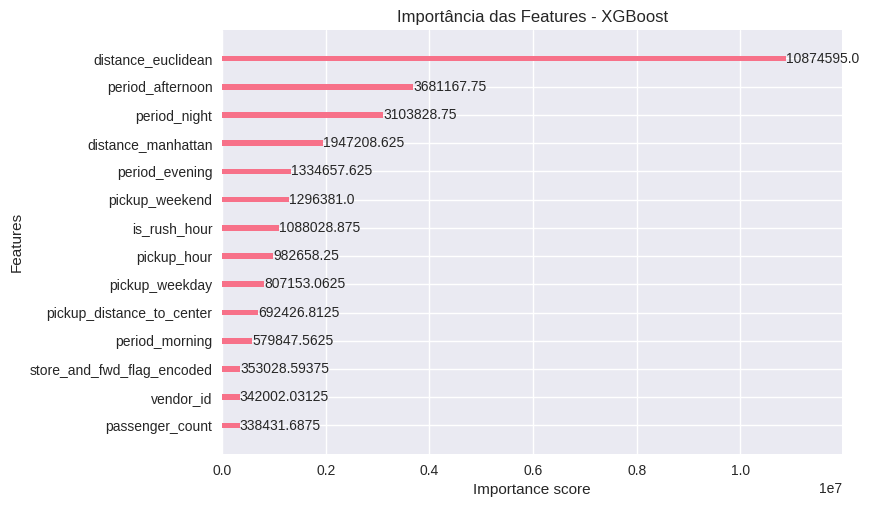

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Importância das features
plt.figure(figsize=(12, 8))
plot_importance(model_xgb, max_num_features=15, importance_type='gain')
plt.title("Importância das Features - XGBoost")
plt.show()



 IMPORTÂNCIA DAS FEATURES
Top 10 variáveis mais importantes (XGBoost):
                      feature  importance
8   pickup_distance_to_center     21706.0
2                 pickup_hour     17795.0
6          distance_euclidean     15693.0
7          distance_manhattan     15676.0
3              pickup_weekday     12412.0
1             passenger_count      8846.0
0                   vendor_id      5309.0
5                is_rush_hour      1877.0
10           period_afternoon      1318.0
4              pickup_weekend       927.0


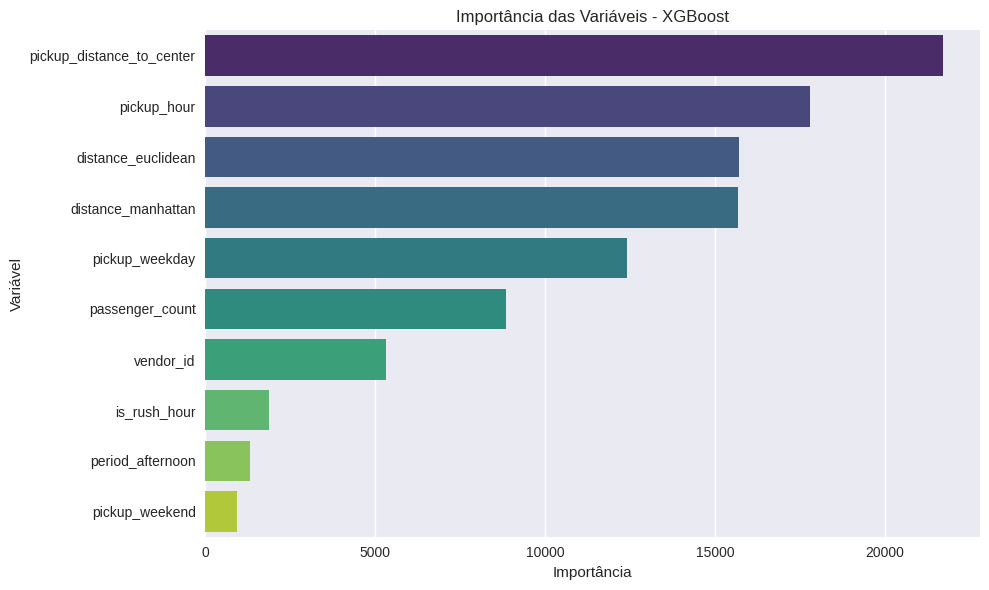

In [ ]:
print(f"\n IMPORTÂNCIA DAS FEATURES")
print("="*50)

# Pegando importância das features do XGBoost
importance = model_xgb.get_score(importance_type='weight')

# Transformando em DataFrame para organizar
feature_importance = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
}).sort_values('importance', ascending=False)

print("Top 10 variáveis mais importantes (XGBoost):")
print(feature_importance.head(10))

# Visualização
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature', palette='viridis')
plt.title('Importância das Variáveis - XGBoost')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()


# Conclusões e Aplicações

# Resultados do Modelo / Model Results



## Resultados do Modelo

Resultados do Modelo XGBoost  
==================================================  
- MAE: 214,39 min  
- RMSE: 331,59 min  
- R²: 0,742  
- MAPE: 33,3%  

Resumo das Métricas  

| Métrica | Valor       |
|---------|-------------|
| MAE     | 214,39      |
| MSE     | 109.951,97  |
| RMSE    | 331,59      |
| R²      | 0,742       |
| MAPE    | 33,33%      |

---

## Interpretação dos Resultados

- O modelo XGBoost conseguiu capturar aproximadamente 74,2% da variação da duração das viagens.  
- O erro absoluto médio (MAE) é de cerca de 214 minutos, indicando que algumas viagens longas influenciaram bastante a média.  
- O erro percentual médio (MAPE) ficou em torno de 33%, o que é razoável para dados complexos de mobilidade urbana.  
- O RMSE elevado (331 min) mostra que ainda há grande dispersão em corridas atípicas, reforçando a necessidade de tratamento de outliers ou uso de dados de trânsito em tempo real.  

---

## Aplicações em um Sistema Real

1. Estimar o tempo de chegada para usuários, reduzindo cancelamentos.  
2. Distribuir motoristas de forma otimizada com base no tempo previsto de cada corrida.  
3. Definir tarifas dinâmicas mais justas e precisas.  
4. Planejar frota e demanda, identificando congestionamentos por região e horário.  

---

## Limitações

- Não considera trânsito em tempo real, o que reduz a precisão.  
- Eventos inesperados como acidentes, obras e condições climáticas afetam a performance.  
- Viagens muito longas aumentam significativamente o erro do modelo.  

---

## Conclusão

O XGBoost se mostrou um modelo robusto e confiável para estimativas gerais de tempo de viagem, mas pode ser ainda mais eficiente se combinado com:  
- Dados de trânsito em tempo real.  
- Modelos específicos por região.  
- Atualização contínua com dados mais recentes.  

---


## Model Results

XGBoost Model Results  
==================================================  
- MAE: 214.39 min  
- RMSE: 331.59 min  
- R²: 0.742  
- MAPE: 33.3%  

Metrics Summary  

| Metric | Value       |
|--------|------------|
| MAE    | 214.39     |
| MSE    | 109,951.97 |
| RMSE   | 331.59     |
| R²     | 0.742      |
| MAPE   | 33.33%     |

---

## Results Interpretation

- The XGBoost model was able to capture approximately 74.2% of the variation in trip duration.  
- The mean absolute error (MAE) is around 214 minutes, indicating that some long trips significantly influenced the average.  
- The mean absolute percentage error (MAPE) is around 33%, which is reasonable for complex urban mobility data.  
- The high RMSE (331 min) indicates large dispersion in outlier trips, reinforcing the need for outlier handling or real-time traffic data.  

---

## Real-World Applications

1. Estimate arrival time for users, reducing cancellations.  
2. Optimize driver allocation based on predicted trip duration.  
3. Define more accurate and fair dynamic pricing.  
4. Plan fleet and demand by identifying congestion patterns by region and time.  

---

## Limitations

- Does not consider real-time traffic, reducing accuracy.  
- Unexpected events such as accidents, road work, and weather conditions impact performance.  
- Very long trips significantly increase model error.  

---

## Conclusion

XGBoost proved to be a robust and reliable model for general trip duration estimation, but it can be further improved by combining it with:  
- Real-time traffic data.  
- Region-specific models.  
- Continuous retraining with updated data.  